# Simulazione d'esame Laboratorio di Programmazione 2

## Esercizio 1

1. Crea un vettore NumPy con i seguenti **canoni mensili d'affitto** (in euro) per 4 appartamenti: **720, 980, 650, 1200**

2. Calcola la **spesa totale mensile** sostenuta dagli inquilini.

3. Il proprietario dell'appartamento da **1200 €** decide di **aumentare l’affitto del 12%**.
    - Modifica il vettore per applicare l’aumento.
    - L’importo aggiornato deve essere esattamente **1344,00 €**, controlla se appare **esattamente** nel tuo array.


4. L'inquilino dell'appartamento da **650 €** ottiene uno **sconto del 10%**.
    - Applica la modifica.

5. Gli altri due appartamenti (**720 € e 980 €**) subiscono un **aumento del 5%**.
    - Aggiorna il vettore di conseguenza.

7. Calcola la **nuova spesa totale mensile** dopo tutti i cambiamenti.

8. Infine: quanto ha influito **l’aumento dell’affitto più alto** sulla spesa complessiva?

    (Suggerimento: confronta la spesa totale **prima di qualsiasi modifica** e **dopo il solo aumento del canone a 1200 €**.)


In [124]:
import numpy as np

canoni_mensili = np.array([720,980,650,1200])

totale_mese = np.sum(canoni_mensili)

canoni_mensili[3] += canoni_mensili[3] * 12 /100

aumento = np.sum(canoni_mensili) - totale_mese

canoni_mensili[0] += canoni_mensili[0] * 5 /100
canoni_mensili[1] += canoni_mensili[3] * 5 /100
canoni_mensili[2] -= canoni_mensili[3] * 10 /100

totale_dopo_aumento = np.sum(canoni_mensili)

canoni_mensili

array([ 756, 1047,  515, 1344])

## Esercizio 2

Consideriamo un semplice processo di random walk (cammino aleatorio) in una dimensione:
a ogni passo temporale, un camminatore si sposta a destra (+1) o a sinistra (-1) con uguale probabilità. Supponiamo che il camminatore parta sempre da x=0.

1. Scrivi una funzione che simula il cammino per n passi ed N camminatori e restituisce due array. Il primo rappresenta la media della posizione ad ogni passo degli N camminatori ed il secondo la deviazione standard della posizione ad ogni passo degli N camminatori.

2. Fai prima il plot della media delle posizione degli N camminatori per 100 passi 

3. Fai il plot con anche la devizione standard.  La deviazione standard diminuisce all'aumentare del campione? Che andamento ha la deviazione standard rispeto l tempo/passi?

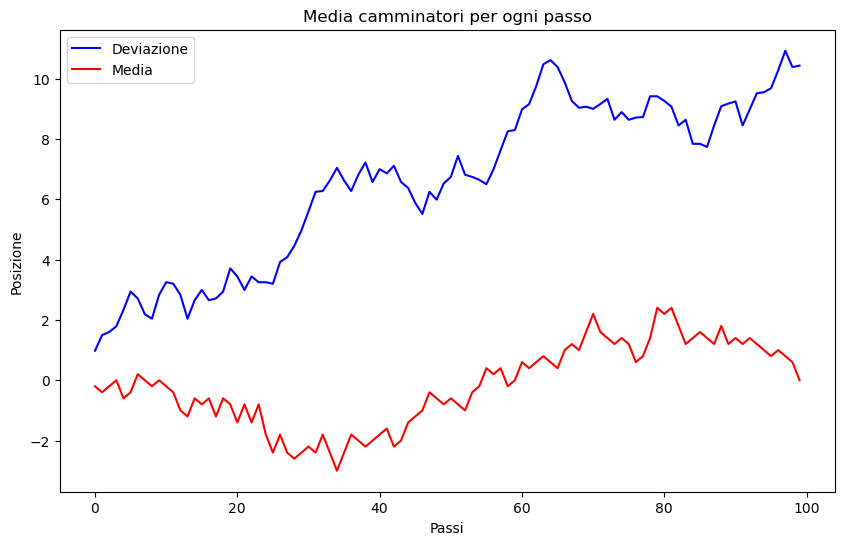

In [125]:
import random
import matplotlib.pyplot as plt

#passi, camminatori
def cammina(n, N):
    all_steps = np.array([random.choice([-1, 1]) for n in range(n * N)]).reshape(N, n)
    #print(all_steps)
    
    posizioni = np.cumsum(all_steps, axis=1)

    media_step = np.mean(posizioni, axis=0)
    dev_stand = np.std(posizioni, axis=0)

    return media_step, dev_stand
    

media, dev = cammina(100,5)

plt.figure(figsize=(10,6)) 

plt.plot(dev, color='blue', label='Deviazione') 
plt.plot(media, color='red', label='Media')
plt.title('Media camminatori per ogni passo')
plt.xlabel('Passi')
plt.ylabel('Posizione')
plt.legend()
plt.show()

## Esercizio 3

Genera un array `a` di dimensioni **5 x 9** contenente numeri da una distribuzione gaussiana con media 0 e dev standard 1.  
Per ogni riga, seleziona il numero **più vicino a 0.1**.
Imposta il seed per la riproducibilità `np.random.seed(42)`

 *Suggerimento*: per ottenere `a[i, j]`, l'array `i` deve contenere gli **indici di riga** corrispondenti agli elementi in `j`.


In [126]:
import numpy as np

np.random.seed(42)

a = np.array([np.random.normal(loc=0, scale=1) for n in range(5 * 9)]).reshape(5,9)

idx = np.array([np.abs(i - 0.1).argmin() for i in a])

a[[n for n in range(len(a))], [i for i in idx]]

array([-0.1382643 ,  0.24196227,  0.11092259, -0.01349722,  0.17136828])

## Esercizio 4

Utilizza il dataset `titanic`, disponibile all'url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

Esegui un’analisi esplorativa sui dati dei passeggeri, focalizzandoti su tariffe, età e componenti familiari.

1. **Visualizza i primi 10 passeggeri ordinati per tariffa pagata** (`Fare`), dal più alto al più basso.

2. **Calcola la media** di:
   - `Age` (età)
   - `Fare` (tariffa)
   - `SibSp` (numero di fratelli/coniugi a bordo)

3. **Crea una nuova colonna** chiamata `Family_index`, definita come:

   $$
   \texttt{family\_index} = \frac{\texttt{sibsp} + \texttt{parch}}{\texttt{fare}}
   $$

   *(Indicatore del “peso familiare” per unità di spesa – attenzione a eventuali divisioni per zero!)*

4. Trova il **passeggero con il valore massimo** di `Family_index`.

5. **Filtra solo i passeggeri** che hanno pagato **più di 100** di tariffa (`Fare > 100`).

6. **Crea un grafico a barre** con i 10 passeggeri che hanno pagato di più (`Fare`).

7. **Crea un grafico a linee** dell’età (`Age`), ordinando i passeggeri per tariffa (`Fare`) crescente.



💡 *Suggerimenti*:
- Ricordati di gestire eventuali valori mancanti in `Age` o `Fare` prima di fare operazioni.


In [248]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '28'),
  Text(1, 0, '32'),
  Text(2, 0, '89'),
  Text(3, 0, '119'),
  Text(4, 0, '196'),
  Text(5, 0, '216'),
  Text(6, 0, '259'),
  Text(7, 0, '269'),
  Text(8, 0, '270'),
  Text(9, 0, '298')])

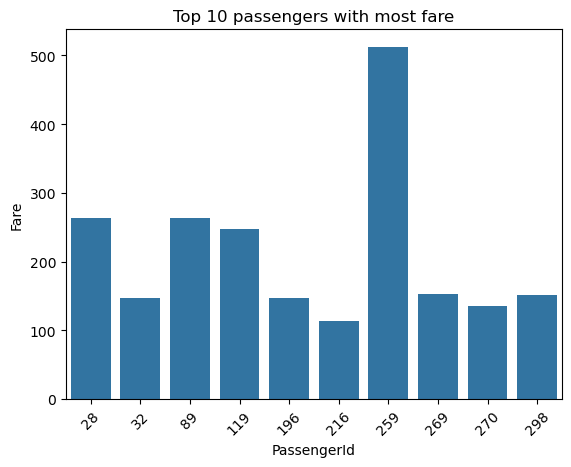

In [249]:
df.sort_values("Fare", ascending=False).head(10)

df['Age'].fillna(df['Age'].mean())
df['Fare'].fillna(df['Fare'].mean())


age_mean = df['Age'].mean()
fare_mean = df['Fare'].mean()
sib_mean = df['SibSp'].mean()

df['Family_index'] = (df['SibSp'] + df['Parch']) + df['Fare']

df[df['Family_index'] == df['Family_index'].max()]

df[df['Fare'] > 100]

sns.barplot(data=df[df['Fare'] > 100].head(10), x='PassengerId', y='Fare')
plt.title('Top 10 passengers with most fare')
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Fare distribution per age')

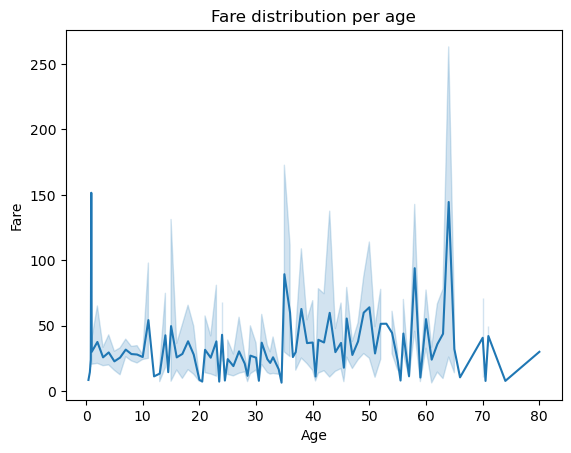

In [250]:
sns.lineplot(data=df.sort_values('Fare'), x='Age', y='Fare')
plt.title('Fare distribution per age')

## Esercizio 5

Usa il dataset `penguins`, disponibile tramite `seaborn.load_dataset("penguins")`.


1. Quante righe e colonne ha il dataset?

2. Controlla quanti valori mancanti ci sono per colonna.

3. Riempi i valori mancanti nella colonna `sex` con il valore più frequente.

4. Rimuovi le righe in cui il valore `body_mass_g` è mancante.

5. Controlla se ci sono righe duplicate.

6. Calcola la **massa corporea media** (`body_mass_g`) per ogni specie (`species`).
  Se ci sono valori mancanti in `body_mass_g`, riempili con la media della specie.

7. Visualizza la **distribuzione della massa corporea** (`body_mass_g`) per specie.

8.  Visualizza la **distribuzione della massa corporea** per specie, **dividendo per sesso** (`sex`) e mostrandoli a confronto.


💡 Suggerimento: usa `seaborn.violinplot()`, `boxplot()` o `kdeplot()` con `hue='sex'`.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
print(f"Data frame has {df.shape[0]} row and {df.shape[1]} column")

print(f'List of Na for columns :\n{df.isna().sum()}')

valore_piu_frequente = df['sex'].mode()[0]
df['sex'] = df['sex'].fillna(valore_piu_frequente)

#df = df.dropna(subset=['body_mass_g'])

print(f'There are {df.duplicated().sum()} duplicates')

species_mean = df['species'].mode()
df['body_mass_g'].fillna(species_mean)

species_grouped_by_mass = df.groupby('species')['body_mass_g'].mean()
vect = df.groupby(['species', 'sex'])['body_mass_g'].mean()

specie_frame = vect.reset_index()
specie_frame

Data frame has 344 row and 7 column
List of Na for columns :
species              0
island               0
bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
sex                  0
dtype: int64
There are 0 duplicates


,species,sex,body_mass_g
0,Adelie,Female,3368.835616
1,Adelie,Male,4011.217949
2,Chinstrap,Female,3527.205882
3,Chinstrap,Male,3938.970588
4,Gentoo,Female,4679.741379
5,Gentoo,Male,5429.615385


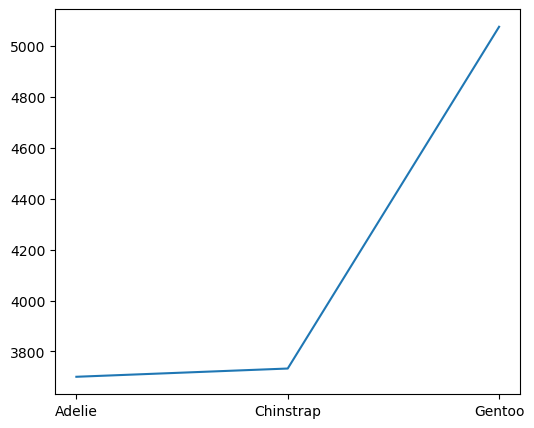

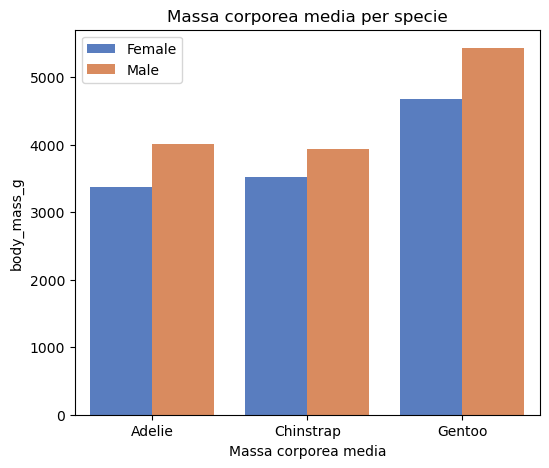

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(species_grouped_by_mass.index, species_grouped_by_mass.values)

plt.figure(figsize=(6,5))
sns.barplot(data=specie_frame, x='species', y='body_mass_g', hue='sex', palette='muted')
plt.legend()
plt.title("Massa corporea media per specie")
plt.xlabel('Specie')
plt.ylabel('Massa corporea media')
plt.show()

## Esercizio 6

Hai due array NumPy generati come segue:

`x = np.linspace(0, 10, 100)`  
`y = 3 * x + 2 + np.random.normal(0, 1, 100)`

Scrivi una funzione `fit_line(x, y)` che:

- usa `scipy.optimize.curve_fit` per eseguire un **fitting lineare** del tipo `y = a * x + b`;  
- restituisce una tupla contenente:
  - i **parametri ottimizzati** `a` e `b`;  
  - una **stringa** che descrive la retta trovata, ad esempio: `"y = 3.02 * x + 1.95"`.


Esempio di output atteso:   (3.02, 1.95, "y = 3.02 * x + 1.95")

Fai un esempio di utilizzo dove poi plotti i dati e la curva ottenuta.


In [256]:
import scipy as sp

x = np.linspace(0, 10, 100)
y_data = 3 * x + 2 + np.random.normal(0, 1, 100)

def linear_model(x, a, b):
    return a * x + b

def fit_line(x, y):
    params, cov = sp.optimize.curve_fit(linear_model, x, y)
    
    a_optimized, b_optimized = params

    retta = f'y = {a_optimized:.4f} * x + {b_optimized:.4f}'
    
    return a_optimized, b_optimized, retta

a, b, eq = fit_line(x, y_data)

print(f"Coefficiente angolare (m): {a:.4f}")
print(f"Intercetta (q): {b:.4f}")
print(f"Retta finale (f): {eq}")

y_fit = linear_model(x, a, b)

Coefficiente angolare (m): 2.9593
Intercetta (q): 2.1098
Retta finale (f): y = 2.9593 * x + 2.1098


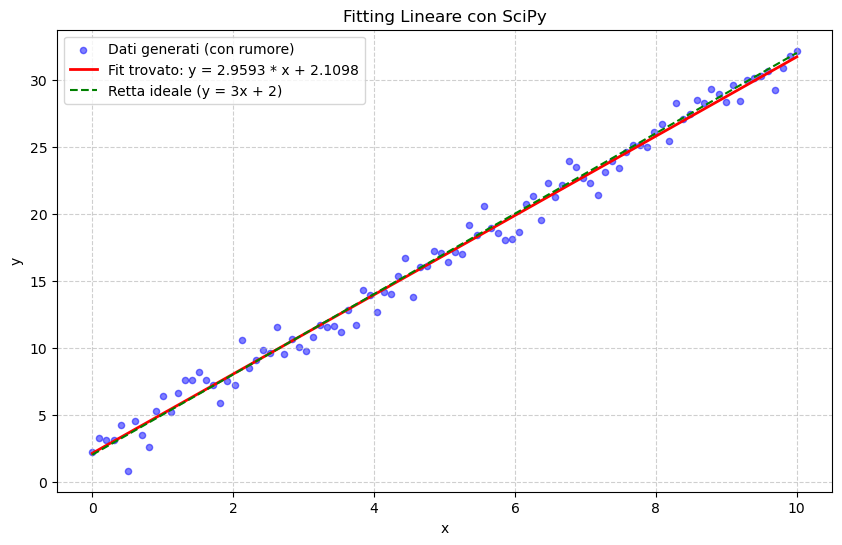

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(x, y_data, color='blue', alpha=0.5, label='Dati generati (con rumore)', s=20)

plt.plot(x, y_fit, color='red', linewidth=2, label=f'Fit trovato: {eq}')

plt.plot(x, 3 * x + 2, color='green', linestyle='--', label='Retta ideale (y = 3x + 2)')

plt.title('Fitting Lineare con SciPy')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()